BiLSTM implementation on the balanced dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
from collections import Counter

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
warnings.filterwarnings('ignore')
sns.set_palette("husl")

# Random seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Random seed: {RANDOM_SEED}")

Device: cuda
Random seed: 42


In [ ]:
#LOADING BALANCED MERGED DATASET

# Load the balanced dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/OurBalancedDataset.csv')

print(f"Dataset loaded!")
print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

# Verify balance
print(f"\nDataset Verification:")
print(f"Languages: {df['language'].value_counts().to_dict()}")
print(f"Binary labels: {df['binary_label'].value_counts().to_dict()}")

# Convert to numeric labels
df['label_numeric'] = df['binary_label'].map({'human': 0, 'machine': 1})

print(f"\nLabels converted: human=0, machine=1")

Dataset loaded!
Total samples: 26,671
Columns: ['text', 'label', 'multi_label', 'language', 'dataset_source', 'binary_label', 'char_length']

Dataset Verification:
Languages: {'es': 6668, 'de': 6668, 'cs': 6668, 'en': 6667}
Binary labels: {'machine': 13336, 'human': 13335}

Labels converted: human=0, machine=1


In [ ]:
# Split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df[['language', 'label_numeric']]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_df[['language', 'label_numeric']]
)

print(f"Split completed:")
print(f"Train: {len(train_df):,} samples (80%)")
print(f"Val:   {len(val_df):,} samples (10%)")
print(f"Test:  {len(test_df):,} samples (10%)")

# Verify balance
print(f"\nTrain set:")
print(f"Labels: {train_df['label_numeric'].value_counts().to_dict()}")
print(f"Languages: {train_df['language'].value_counts().to_dict()}")

Split completed:
Train: 21,336 samples (80%)
Val:   2,667 samples (10%)
Test:  2,668 samples (10%)

Train set:
Labels: {1: 10668, 0: 10668}
Languages: {'en': 5334, 'cs': 5334, 'de': 5334, 'es': 5334}


In [ ]:
#BUILDING VOCABULARY

class Vocabulary:
    def __init__(self, min_freq=2):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.word_freq = Counter()
        self.min_freq = min_freq

    def build_vocab(self, texts):
        # Count word frequencies
        for text in texts:
            words = str(text).lower().split()
            self.word_freq.update(words)

        # Add words that appear at least min_freq times
        idx = 2  # Start after PAD and UNK
        for word, freq in self.word_freq.items():
            if freq >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        return self

    def encode(self, text):
        words = str(text).lower().split()
        return [self.word2idx.get(word, 1) for word in words]  # 1 is <UNK>

    def __len__(self):
        return len(self.word2idx)

# Build vocabulary from training data
vocab = Vocabulary(min_freq=2)
vocab.build_vocab(train_df['text'])

print(f"Vocabulary built")
print(f"Vocabulary size: {len(vocab):,}")
print(f"Min frequency: {vocab.min_freq}")
print(f"Total unique words in corpus: {len(vocab.word_freq):,}")
print(f"Words kept (freq >= {vocab.min_freq}): {len(vocab)-2:,}")

Vocabulary built!
Vocabulary size: 124,807
Min frequency: 2
Total unique words in corpus: 341,634
Words kept (freq >= 2): 124,805


In [ ]:
#CREATING PYTORCH DATASETS
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]

        # Encode text
        encoded = self.vocab.encode(text)

        # Truncate if too long
        if len(encoded) > self.max_len:
            encoded = encoded[:self.max_len]

        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_batch(batch):
    #Collate function to pad sequences in a batch
    texts, labels = zip(*batch)

    # Pad sequences
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)

    return texts_padded, labels

# Create datasets
MAX_LEN = 256
BATCH_SIZE = 32

train_dataset = TextDataset(train_df['text'], train_df['label_numeric'], vocab, MAX_LEN)
val_dataset = TextDataset(val_df['text'], val_df['label_numeric'], vocab, MAX_LEN)
test_dataset = TextDataset(test_df['text'], test_df['label_numeric'], vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print(f"PyTorch datasets created")
print(f"Max sequence length: {MAX_LEN}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

PyTorch datasets created!
Max sequence length: 256
Batch size: 32
Train batches: 667
Val batches: 84
Test batches: 84


In [ ]:
# DEFINING BiLSTM MODEL
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128,
                 num_layers=2, dropout=0.3, num_classes=2):
        super(BiLSTMClassifier, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # BiLSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        # BiLSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        # Dropout
        out = self.dropout(hidden_concat)
        # FC layer
        out = self.fc(out)  # (batch_size, num_classes)
        return out

# Model hyperparameters
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
NUM_CLASSES = 2

# Initialize model
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"BiLSTM Model initialized!")
print(f"\nArchitecture:")
print(f"Vocabulary size: {len(vocab):,}")
print(f"Embedding dim: {EMBEDDING_DIM}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Num layers: {NUM_LAYERS}")
print(f"Bidirectional: True")
print(f"Dropout: {DROPOUT}")
print(f"Output classes: {NUM_CLASSES}")

print(f"\nParameters:")
print(f"Total: {total_params:,}")
print(f"Trainable: {trainable_params:,}")

print(f"\n {model}")

BiLSTM Model initialized!

Architecture:
Vocabulary size: 124,807
Embedding dim: 128
Hidden dim: 128
Num layers: 2
Bidirectional: True
Dropout: 0.3
Output classes: 2

Parameters:
Total: 16,635,266
Trainable: 16,635,266

 BiLSTMClassifier(
  (embedding): Embedding(124807, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
#TRAINING SETUP
# Training hyperparameters
EPOCHS = 10
LEARNING_RATE = 0.001
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Monitor F1 (maximize)
    factor=0.5,
    patience=2,
)
print(f"Training configuration:")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Loss: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau")
print(f"Device: {device}")

Training configuration:
Epochs: 10
Learning rate: 0.001
Optimizer: Adam
Loss: CrossEntropyLoss
Scheduler: ReduceLROnPlateau
Device: cuda


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1

def evaluate(model, loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1, precision, recall, all_preds, all_labels

In [ ]:
#TRAINING BiLSTM

best_val_f1 = 0
best_epoch = 0
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print(f"Training for {EPOCHS} epochs...\n")
for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    # Validate
    val_loss, val_acc, val_f1, val_precision, val_recall, _, _ = evaluate(model, val_loader, criterion, device)
    # Update scheduler
    scheduler.step(val_f1)
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    # Print progress
    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/bilstm_best_model.pt')
        print(f"Best model saved! (F1: {val_f1:.4f})")
    print()
print(f"Best validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")


Training for 10 epochs...

Epoch 1/10 (8.4s):
  Train - Loss: 0.1203, Acc: 0.9564, F1: 0.9564
  Val   - Loss: 0.2168, Acc: 0.9213, F1: 0.9212
Best model saved! (F1: 0.9212)

Epoch 2/10 (8.4s):
  Train - Loss: 0.0537, Acc: 0.9813, F1: 0.9813
  Val   - Loss: 0.3730, Acc: 0.8871, F1: 0.8866

Epoch 3/10 (8.4s):
  Train - Loss: 0.0211, Acc: 0.9937, F1: 0.9937
  Val   - Loss: 0.2985, Acc: 0.9160, F1: 0.9160

Epoch 4/10 (8.4s):
  Train - Loss: 0.0079, Acc: 0.9975, F1: 0.9975
  Val   - Loss: 0.3846, Acc: 0.9175, F1: 0.9175

Epoch 5/10 (8.4s):
  Train - Loss: 0.0027, Acc: 0.9993, F1: 0.9993
  Val   - Loss: 0.3965, Acc: 0.9153, F1: 0.9152

Epoch 6/10 (8.4s):
  Train - Loss: 0.0010, Acc: 0.9997, F1: 0.9997
  Val   - Loss: 0.4798, Acc: 0.9160, F1: 0.9159

Epoch 7/10 (8.4s):
  Train - Loss: 0.0002, Acc: 1.0000, F1: 1.0000
  Val   - Loss: 0.5189, Acc: 0.9164, F1: 0.9163

Epoch 8/10 (8.4s):
  Train - Loss: 0.0001, Acc: 1.0000, F1: 1.0000
  Val   - Loss: 0.5603, Acc: 0.9160, F1: 0.9159

Epoch 9/10 (8.

In [ ]:
#TEST SET EVALUATION
# Load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/bilstm_best_model.pt'))
print(f"Loaded best model from epoch {best_epoch}")

# Evaluate on test set
test_loss, test_acc, test_f1, test_precision, test_recall, y_pred, y_true = evaluate(
    model, test_loader, criterion, device
)
print(f"\nTest Set Metrics:")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Macro-F1:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Human', 'Machine'],digits=4))

Loaded best model from epoch 1

Test Set Metrics:
Accuracy:  0.9247
Macro-F1:  0.9247
Precision: 0.9248
Recall:    0.9247

Detailed Classification Report:
              precision    recall  f1-score   support

       Human     0.9180    0.9325    0.9252      1333
     Machine     0.9315    0.9169    0.9241      1335

    accuracy                         0.9247      2668
   macro avg     0.9248    0.9247    0.9247      2668
weighted avg     0.9248    0.9247    0.9247      2668



In [ ]:
!pip install optuna -q
import optuna
from optuna.trial import TrialState

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 29.9 MB/s eta 0:00:00


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128,
                 num_layers=2, dropout=0.3, num_classes=2):
        super(BiLSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.dropout(hidden_concat)
        out = self.fc(out)
        return out

In [ ]:
def objective(trial):
    params = {
        'embedding_dim': trial.suggest_categorical('embedding_dim', [64, 128, 256]),
        'hidden_dim': trial.suggest_categorical('hidden_dim', [64, 128, 256]),
        'num_layers': trial.suggest_int('num_layers', 1, 3),
        'dropout': trial.suggest_float('dropout', 0.2, 0.5, step=0.1),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-2),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64])
    }

    # Create data loaders with trial's batch size
    train_loader_trial = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True, collate_fn=collate_batch)
    val_loader_trial = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_batch)

    # Create model with trial's hyperparameters
    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embedding_dim=params['embedding_dim'],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        dropout=params['dropout'],
        num_classes=2
    ).to(device)

    # Training setup
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])

    # Progressive training (Hyperband evaluates at each epoch)
    for epoch in range(15):
        # Training phase
        model.train()
        for texts, labels in train_loader_trial:
            texts, labels = texts.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation phase
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for texts, labels in val_loader_trial:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')

        # Report to Hyperband for adaptive pruning based on performance
        trial.report(val_f1, epoch)

        # Check if Hyperband decided to prune this trial
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_f1

In [ ]:
#hyperband optimization
from optuna.pruners import HyperbandPruner
# Create study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=HyperbandPruner(
        min_resource=3,
        max_resource=15,
        reduction_factor=3
    )
)
# Run optimization
study.optimize(objective, n_trials=30, show_progress_bar=True)


[I 2025-11-30 01:40:55,085] A new study created in memory with name: no-name-f5e67c69-570a-4833-91a6-375728f03af8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-30 01:41:43,744] Trial 0 finished with value: 0.9249797470633242 and parameters: {'embedding_dim': 128, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.5, 'learning_rate': 0.0006358358856676254, 'batch_size': 64}. Best is trial 0 with value: 0.9249797470633242.
[I 2025-11-30 01:42:34,219] Trial 1 pruned. 
[I 2025-11-30 01:42:58,871] Trial 2 pruned. 
[I 2025-11-30 01:49:09,479] Trial 3 finished with value: 0.8987913330125344 and parameters: {'embedding_dim': 256, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.5, 'learning_rate': 5.9750279999602906e-05, 'batch_size': 16}. Best is trial 0 with value: 0.9249797470633242.
[I 2025-11-30 01:49:50,202] Trial 4 pruned. 
[I 2025-11-30 01:51:29,271] Trial 5 pruned. 
[I 2025-11-30 01:54:01,749] Trial 6 finished with value: 0.9283723109402449 and parameters: {'embedding_dim': 128, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0038842777547031426, 'batch_size': 16}. Best is trial 6 with value: 0.9283723109402449

In [ ]:
#Best Hyperparam
best_params = study.best_params
for param, value in best_params.items():
    print(f"{param:20s}: {value}")
print(f"\nBest Validation F1: {study.best_value:.4f}")

# Statistics
n_complete = len([t for t in study.trials if t.state == TrialState.COMPLETE])
n_pruned = len([t for t in study.trials if t.state == TrialState.PRUNED])

print(f"\nStatistics:")
print(f"Completed trials: {n_complete}")
print(f"Pruned trials: {n_pruned} (saved ~{n_pruned*10} epoch)")

# Top 5
trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state']=='COMPLETE'].sort_values('value', ascending=False)

print(f"\nTop 5 trials:")
for i, (idx, row) in enumerate(completed.head(5).iterrows(), 1):
    params = {k.replace('params_',''): v for k,v in row.items() if k.startswith('params_')}
    print(f"{i}. F1={row['value']:.4f} | {params}")

embedding_dim       : 256
hidden_dim          : 128
num_layers          : 2
dropout             : 0.5
learning_rate       : 0.0025764174425233167
batch_size          : 32

Best Validation F1: 0.9430

Statistics:
Completed trials: 10
Pruned trials: 20 (saved ~200 epoch)

Top 5 trials:
1. F1=0.9430 | {'batch_size': 32, 'dropout': 0.5, 'embedding_dim': 256, 'hidden_dim': 128, 'learning_rate': 0.0025764174425233167, 'num_layers': 2}
2. F1=0.9411 | {'batch_size': 32, 'dropout': 0.4, 'embedding_dim': 128, 'hidden_dim': 128, 'learning_rate': 0.0047438643984888465, 'num_layers': 2}
3. F1=0.9393 | {'batch_size': 32, 'dropout': 0.4, 'embedding_dim': 256, 'hidden_dim': 128, 'learning_rate': 0.0025392995491192397, 'num_layers': 3}
4. F1=0.9351 | {'batch_size': 32, 'dropout': 0.30000000000000004, 'embedding_dim': 128, 'hidden_dim': 128, 'learning_rate': 0.001097540652609533, 'num_layers': 2}
5. F1=0.9336 | {'batch_size': 32, 'dropout': 0.4, 'embedding_dim': 128, 'hidden_dim': 128, 'learning_rate': 

In [ ]:
#Saving results
trials_df.to_csv('/content/drive/MyDrive/Colab Notebooks/bilstm_hyperband_trials.csv', index=False)

with open('/content/drive/MyDrive/Colab Notebooks/bilstm_best_params.json', 'w') as f:
    json.dump({
        'method': 'Hyperband',
        'best_params': best_params,
        'best_val_f1': float(study.best_value),
        'n_trials': 30,
        'n_completed': n_complete,
        'n_pruned': n_pruned}, f, indent=2)

In [ ]:
# DEFINING BiLSTM MODEL

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128,
                 num_layers=2, dropout=0.3, num_classes=2):
        super(BiLSTMClassifier, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # BiLSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        # BiLSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Concatenate final forward and backward hidden states
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        # Dropout
        out = self.dropout(hidden_concat)
        # FC layer
        out = self.fc(out)  # (batch_size, num_classes)
        return out

# Model hyperparameters
EMBEDDING_DIM = 256
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.5
NUM_CLASSES = 2

# Initialize model
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"BiLSTM Model initialized!")
print(f"\nArchitecture:")
print(f"Vocabulary size: {len(vocab):,}")
print(f"Embedding dim: {EMBEDDING_DIM}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Num layers: {NUM_LAYERS}")
print(f"Bidirectional: True")
print(f"Dropout: {DROPOUT}")
print(f"Output classes: {NUM_CLASSES}")

print(f"\nParameters:")
print(f"Total: {total_params:,}")
print(f"Trainable: {trainable_params:,}")

print(f"\n {model}")

BiLSTM Model initialized!

Architecture:
Vocabulary size: 124,807
Embedding dim: 256
Hidden dim: 128
Num layers: 2
Bidirectional: True
Dropout: 0.5
Output classes: 2

Parameters:
Total: 32,741,634
Trainable: 32,741,634

 BiLSTMClassifier(
  (embedding): Embedding(124807, 256, padding_idx=0)
  (lstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
#TRAINING SETUP
# Training hyperparameters
EPOCHS = 10
LEARNING_RATE = 0.00258
print(f"Learning rate: {LEARNING_RATE:.5f} (optimized by Hyperband)")
print(f"Original LR was: 0.001")

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Monitor F1 (maximize)
    factor=0.5,
    patience=2,
)

print(f"Training configuration:")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Loss: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau")
print(f"Device: {device}")

Learning rate: 0.00258 (optimized by Hyperband)
Original LR was: 0.001
Training configuration:
Epochs: 10
Learning rate: 0.00258
Optimizer: Adam
Loss: CrossEntropyLoss
Scheduler: ReduceLROnPlateau
Device: cuda


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1

def evaluate(model, loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1, precision, recall, all_preds, all_labels

In [ ]:
#TRAINING BiLSTM

best_val_f1 = 0
best_epoch = 0
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}
print(f"Training for {EPOCHS} epochs\n")
for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, val_f1, val_precision, val_recall, _, _ = evaluate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_f1)
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    # Print progress
    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/bilstm_best_tuned_model.pt')
        print(f"Best model saved! (F1: {val_f1:.4f})")
    print()
print(f"Training completed")
print(f"Best validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")


Training for 10 epochs

Epoch 1/10:
  Train - Loss: 0.0140, Acc: 0.9991, F1: 0.9991
  Val   - Loss: 0.7191, Acc: 0.9325, F1: 0.9325
Best model saved! (F1: 0.9325)

Epoch 2/10:
  Train - Loss: 0.0023, Acc: 0.9996, F1: 0.9996
  Val   - Loss: 0.5960, Acc: 0.9366, F1: 0.9366
Best model saved! (F1: 0.9366)

Epoch 3/10:
  Train - Loss: 0.0014, Acc: 0.9999, F1: 0.9999
  Val   - Loss: 0.6693, Acc: 0.9273, F1: 0.9272

Epoch 4/10:
  Train - Loss: 0.0024, Acc: 0.9994, F1: 0.9994
  Val   - Loss: 0.7162, Acc: 0.9254, F1: 0.9254

Epoch 5/10:
  Train - Loss: 0.0041, Acc: 0.9990, F1: 0.9990
  Val   - Loss: 0.6630, Acc: 0.9295, F1: 0.9295

Epoch 6/10:
  Train - Loss: 0.0015, Acc: 0.9997, F1: 0.9997
  Val   - Loss: 0.7515, Acc: 0.9306, F1: 0.9306

Epoch 7/10:
  Train - Loss: 0.0010, Acc: 0.9999, F1: 0.9999
  Val   - Loss: 0.6692, Acc: 0.9228, F1: 0.9227

Epoch 8/10:
  Train - Loss: 0.0001, Acc: 1.0000, F1: 1.0000
  Val   - Loss: 0.7607, Acc: 0.9243, F1: 0.9243

Epoch 9/10:
  Train - Loss: 0.0001, Acc: 1

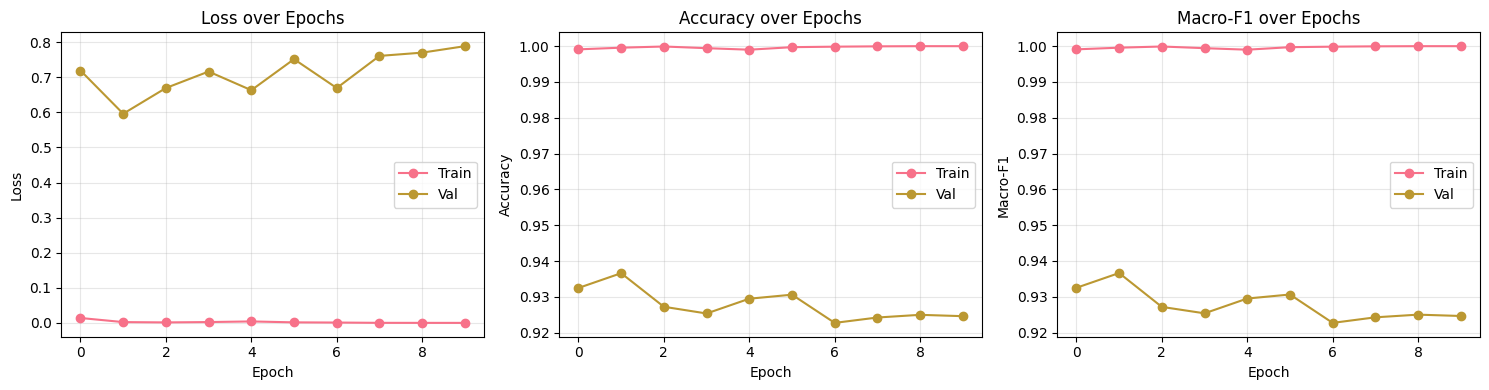

In [ ]:
#TRAINING HISTORY
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(history['train_f1'], label='Train', marker='o')
axes[2].plot(history['val_f1'], label='Val', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('Macro-F1 over Epochs')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/bilstm_tuned_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#TEST SET EVALUATION

# Load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/bilstm_best_tuned_model.pt'))
print(f"Loaded best model from epoch {best_epoch}")

# Evaluate on test set
test_loss, test_acc, test_f1, test_precision, test_recall, y_pred, y_true = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Set Metrics:")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Macro-F1:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Human', 'Machine'],digits=4))

Loaded best model from epoch 2

Test Set Metrics:
Accuracy:  0.9340
Macro-F1:  0.9340
Precision: 0.9341
Recall:    0.9340

Detailed Classification Report:
              precision    recall  f1-score   support

       Human     0.9373    0.9302    0.9337      1333
     Machine     0.9309    0.9378    0.9343      1335

    accuracy                         0.9340      2668
   macro avg     0.9341    0.9340    0.9340      2668
weighted avg     0.9341    0.9340    0.9340      2668



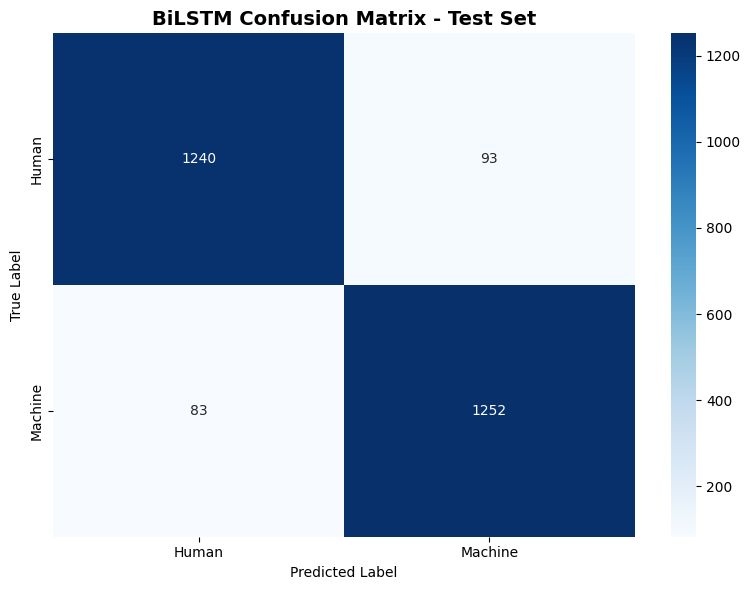

In [ ]:
#CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'Machine'],
            yticklabels=['Human', 'Machine'])
plt.title('BiLSTM Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/bilstm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#PERFORMANCE BY LANGUAGE (Test Set)
languages = ['cs', 'de', 'en', 'es']
lang_results = []

for lang in languages:
    # Filter test data for this language
    lang_indices = test_df[test_df['language'] == lang].index.tolist()

    # Get predictions for this language
    lang_true = []
    lang_pred = []

    # We need to map back from dataset indices to prediction indices
    test_df_reset = test_df.reset_index(drop=True)
    lang_mask = test_df_reset['language'] == lang
    lang_positions = np.where(lang_mask)[0]

    lang_true = np.array(y_true)[lang_positions]
    lang_pred = np.array(y_pred)[lang_positions]

    if len(lang_true) > 0:
        lang_acc = accuracy_score(lang_true, lang_pred)
        lang_f1 = f1_score(lang_true, lang_pred, average='macro')
        lang_precision = precision_score(lang_true, lang_pred, average='macro')
        lang_recall = recall_score(lang_true, lang_pred, average='macro')

        lang_results.append({
            'Language': lang.upper(),
            'Samples': len(lang_true),
            'Accuracy': f"{lang_acc:.4f}",
            'Macro-F1': f"{lang_f1:.4f}",
            'Precision': f"{lang_precision:.4f}",
            'Recall': f"{lang_recall:.4f}"
        })

lang_df = pd.DataFrame(lang_results)
print(lang_df.to_string(index=False))

avg_lang_f1 = np.mean([float(r['Macro-F1']) for r in lang_results])
print(f"\nAverage F1 across languages: {avg_lang_f1:.4f}")

Language  Samples Accuracy Macro-F1 Precision Recall
      CS      666   0.9099   0.9099    0.9100 0.9099
      DE      668   0.9326   0.9326    0.9340 0.9326
      EN      667   0.9415   0.9414    0.9441 0.9415
      ES      667   0.9520   0.9520    0.9520 0.9520

Average F1 across languages: 0.9340


In [ ]:
#LOADING CROSS-LINGUAL TEST DATA

# Load original MULTITuDE for unseen languages
df_multitude_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/multitude_v3_clean.csv')

CROSSLING_LANGUAGES = ['pt', 'nl', 'ru']

crossling_data = {}
for lang in CROSSLING_LANGUAGES:
    lang_df = df_multitude_full[df_multitude_full['language'] == lang].copy()

    # Create binary label
    lang_df['binary_label'] = lang_df['multi_label'].apply(
        lambda x: 'human' if str(x).lower() == 'human' else 'machine'
    )
    lang_df['label_numeric'] = lang_df['binary_label'].map({'human': 0, 'machine': 1})

    crossling_data[lang] = lang_df

    print(f"{lang.upper()}: {len(lang_df):,} samples")
    print(f"   Human: {sum(lang_df['label_numeric']==0):,} | Machine: {sum(lang_df['label_numeric']==1):,}")

print(f"\nCross-lingual test data loaded")

PT: 10,344 samples
   Human: 1,299 | Machine: 9,045
NL: 10,344 samples
   Human: 1,299 | Machine: 9,045
RU: 10,327 samples
   Human: 1,300 | Machine: 9,027

Cross-lingual test data loaded


In [ ]:
#CROSS-LINGUAL EVALUATION (Unseen Languages)

model.eval()
crossling_results = []
for lang in CROSSLING_LANGUAGES:
    print(f"\nEvaluating on {lang.upper()}...")

    # Create dataset for this language
    crossling_dataset = TextDataset(
        crossling_data[lang]['text'],
        crossling_data[lang]['label_numeric'],
        vocab,
        MAX_LEN
    )
    crossling_loader = DataLoader(
        crossling_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_batch
    )
    # Evaluate
    _, acc, f1, precision, recall, preds, labels = evaluate(
        model, crossling_loader, criterion, device
    )

    crossling_results.append({
        'Language': lang.upper(),
        'Samples': len(crossling_data[lang]),
        'Accuracy': f"{acc:.4f}",
        'Macro-F1': f"{f1:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}"
    })

    print(f"  {lang.upper()}: F1={f1:.4f}, Acc={acc:.4f}")

# Summary
print(f"\nCross-Lingual Results:")
crossling_df = pd.DataFrame(crossling_results)
print(crossling_df.to_string(index=False))

avg_crossling_f1 = np.mean([float(r['Macro-F1']) for r in crossling_results])
performance_drop = test_f1 - avg_crossling_f1
drop_percentage = (performance_drop / test_f1) * 100

print(f"\nCross-Lingual Performance:")
print(f"Average F1: {avg_crossling_f1:.4f}")
print(f"Seen languages F1: {test_f1:.4f}")
print(f"Performance drop: {performance_drop:.4f} ({drop_percentage:.1f}%)")


Evaluating on PT...
  PT: F1=0.3451, Acc=0.3574

Evaluating on NL...
  NL: F1=0.3231, Acc=0.3292

Evaluating on RU...
  RU: F1=0.5059, Acc=0.6603

Cross-Lingual Results:
Language  Samples Accuracy Macro-F1 Precision Recall
      PT    10344   0.3574   0.3451    0.5452 0.5798
      NL    10344   0.3292   0.3231    0.5558 0.5874
      RU    10327   0.6603   0.5059    0.5254 0.5499

Cross-Lingual Performance:
Average F1: 0.3914
Seen languages F1: 0.9340
Performance drop: 0.5427 (58.1%)
